In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os

In [71]:
#function
#ABS
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=3e-6):
    d = H_q.shape[0]
    
    # 构造复能量矩阵 (简化的写法，等价于你的 EI_gai)
    EI_gai = (E + 1j * eta) * np.eye(d, dtype=complex)

    # 1. 计算左引线自能
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # 2. 计算右引线自能
    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法提取 G_00 和 G_01
    # ==========================================
    ALR = EI_gai - H_q
    V = T_12
    
    # 3. Right-to-Left 扫掠：只记录向右连通的等效格林函数 gR
    gR = np.zeros((N, d, d), dtype=complex)
    gR[N-1] = np.linalg.inv(ALR - Sigma_R)
    
    # 从 N-2 往 1 递推，把右侧的物理效应不断折叠为等效自能
    for n in range(N-2, 0, -1):
        gR[n] = np.linalg.inv(ALR - V @ gR[n+1] @ V.conj().T)
        
    # 4. 算出真正的左上角 4x4 格林函数 G_00 (原 G_DD_r[0:4, 0:4])
    # 在最左侧 n=0 处，加上左引线的自能 Sigma_L
    G_00 = np.linalg.inv(ALR - V @ gR[1] @ V.conj().T - Sigma_L)
    
    # 5. 算出左上角右侧相邻的 4x4 非对角块 G_01 (原 G_DD_r[0:4, 4:8])
    # 根据 Dyson 方程，G_01 = G_00 * V_01 * gR_1
    #G_01 = G_00 @ V @ gR[1]

    # 返回你需要的结果 (去掉了庞大无用的 A_DD)
    return G_00, G_00, Sigma_R, Sigma_L

def bufeng(G_00):
    d = H_q.shape[0]
    yigeshu=np.trace(G_00)
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


#current
def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    
    # 构造松原频率复能量矩阵
    # 假设外部已经定义了 s0 = np.eye(2, dtype=complex)
    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    # 1. 计算左引线自能
    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # 2. 计算右引线自能
    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法提取 Matsubara G_00, G_01 和 G_10
    # ==========================================
    ALR = EI_gai - H_q
    V = T_12

    # 特殊情况防错：如果 N=1，只有1个格点
    if N == 1:
        G_00 = np.linalg.inv(ALR - Sigma_L - Sigma_R)
        G_01 = np.zeros((d, d), dtype=complex)
        G_10 = np.zeros((d, d), dtype=complex)
        return G_00, G_01, G_10, Sigma_R, Sigma_L

    # 3. Right-to-Left 扫掠：只记录向右连通的等效松原格林函数 gR
    gR = np.zeros((N, d, d), dtype=complex)
    gR[N-1] = np.linalg.inv(ALR - Sigma_R)
    
    # 从 N-2 往 1 递推，把右侧的物理效应不断折叠为等效自能
    for n in range(N-2, 0, -1):
        gR[n] = np.linalg.inv(ALR - V @ gR[n+1] @ V.conj().T)
        
    # 4. 算出真正的左上角 4x4 松原格林函数 G_00
    # 在最左侧 n=0 处，加上左引线的自能 Sigma_L
    G_00 = np.linalg.inv(ALR - V @ gR[1] @ V.conj().T - Sigma_L)
    
    # 5. 算出右侧相邻的非对角块 G_01
    # 公式: G_{0,1} = G_{0,0} * V * gR_1
    G_01 = G_00 @ V @ gR[1]

    # 6. 算出下方相邻的非对角块 G_10
    # 公式: G_{1,0} = gR_1 * V^\dagger * G_{0,0}
    G_10 = gR[1] @ V.conj().T @ G_00

    # 返回优化后的结果 
    return G_00, G_01, G_10, Sigma_R, Sigma_L

def J_wn(G_01, G_10, T_12):
    d = T_12.shape[0]

    G_q_q1 = G_01
    G_q1_q = G_10

    Jmat = (T_12 @ G_q1_q - G_q_q1 @ T_12.conj().T)
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT*(1)
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        _, G_01, G_10, _, _ = Gr_DD_MS(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_01, G_10, T_12))
    return (J_sum)

def J_of_phi(phi):
    H_l = H_onsite(hx,hz,saimanjiao,1,phi,t)
    H_q = H_onsite(mx,mz,zhongjian_saimanjiao,2,phi,t)
    H_r = H_onsite(hx,hz,saimanjiao,3,phi,t)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N)
    return Jphi

def find_J_extreme_fmin(phi_min=0*np.pi, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-4, ftol=1e-4,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])

        # 最小值
        rmin = fmin(lambda phi: J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    J_max = max(J_of_phi(phi) for phi in phi_max_list)
    J_min = min(J_of_phi(phi) for phi in phi_min_list)


    J_max = -np.inf
    phi_at_Jmax = None

    for phi in phi_max_list:
        val = J_of_phi(phi)
        if val > J_max:
            J_max = val
            phi_at_Jmax = phi

    J_min = np.inf
    phi_at_Jmin = None

    for phi in phi_min_list:
        val = J_of_phi(phi)
        if val < J_min:
            J_min = val
            phi_at_Jmin = phi

    yinzi =abs(abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, phi_at_Jmax/np.pi, J_min, phi_at_Jmin/np.pi, yinzi


In [ ]:
#参数 2026.4.8
dela = 1
chaodaojiao = 0
a=1
t =200
af =50
mu = 0
tc=1# 耦合系数

#两边
hx=0.5  #0.5
hz=0.5 #0.95
#(my = 0.954776)
saimanjiao = np.pi*0

#中间
mx= 0.5 #hx #0.5
mz= 0.5    #hz  #0.95
zhongjian_saimanjiao=np.pi*0
af2=1
U_c=0

T_Tc=1e-4
Delta = dela* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=2
dianshubei=0.1#8
KBT=2 * dela * T_Tc / 3.5
shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao,t,renyixiang=0):
    if weizhi==1:
        Delta_X= Delta * np.exp(1j*renyixiang) * 1j * sy #-1 ?
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==2:
        Delta_X=np.zeros((2,2))
        HX_block=(U_c-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af,t):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(hx,hz,saimanjiao,1,chaodaojiao,t)
H_L_right_to_left_hop=H_hop(af,t)

#中间矩阵信息
H_center_to_L=H_hop(0,t*tc)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao,t)
H_center_right_to_left_hop=H_hop(af2*af,t)

H_R_to_center=H_hop(0,t*tc)

#右边矩阵信息
H_R_onsite=H_onsite(hx,hz,saimanjiao,3,chaodaojiao,t)
H_R_right_to_left_hop=H_hop(af,t)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center

In [86]:
#参数
t =1
dela = 0.01*t
chaodaojiao = 0
a=1
af =0
mu = -1.5*t
tc=1# 耦合系数

#两边
hx=0.005*t  #0.5
hz=0 #0.95
#(my = 0.954776)
saimanjiao = np.pi*0

#中间
mx= 0 #hx #0.5
mz= 0    #hz  #0.95
zhongjian_saimanjiao=np.pi*0
af2=0
U_c=0

T_Tc=1e-3
Delta = dela* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=2
dianshubei=0.4#8
KBT=2 * dela * T_Tc / 3.5
shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao,t,renyixiang=0):
    if weizhi==1:
        Delta_X= Delta * np.exp(1j*renyixiang) * 1j * sy #-1 ?
        HX_block=-(mu)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==2:
        Delta_X=np.zeros((2,2))
        HX_block=(U_c-(mu))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af,t):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(hx,hz,saimanjiao,1,chaodaojiao,t)
H_L_right_to_left_hop=H_hop(af,t)

#中间矩阵信息
H_center_to_L=H_hop(0,t*tc)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao,t)
H_center_right_to_left_hop=H_hop(af2*af,t)

H_R_to_center=H_hop(0,t*tc)

#右边矩阵信息
H_R_onsite=H_onsite(hx,hz,saimanjiao,3,chaodaojiao,t)
H_R_right_to_left_hop=H_hop(af,t)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop

H_l= H_L_onsite
T_l= H_L_right_to_left_hop.conj().T

H_r= H_R_onsite
T_r=H_R_right_to_left_hop

T_LD=H_center_to_L
T_RD= H_R_to_center.conj().T


In [9]:
#保存函数（图片）
params_str = (
    f"hz={hz}D_hx={hx}D_a1={af}_jiao={saimanjiao:.3f}_tc={tc}t_N={N}_"
    f"mz={mz}D_mx={mx}D_a2={af*af2}_zjiao={zhongjian_saimanjiao:.3f}_Uc={U_c}_"
    f"TTc={T_Tc}_Delta={dela}meV_t={t/dela:.1f}D_mu={mu/dela:.1f}D"
)

# 清洗文件夹名称中的非法字符
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')

# --- 2. 设置保存根目录 ---
# 这里会自动填充你要求的参数信息
save_dir = rf"D:\结果\2026.4.5\{params_str}"
os.makedirs(save_dir, exist_ok=True)

# --- 3. 修改后的保存函数 ---
def save_fig_by_title(name):
    # a. 清洗文件名（去除非法字符和 LaTeX 符号）
    safe_name = name
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')

    # b. 构造完整路径
    filename = os.path.join(save_dir, safe_name + ".png")

    # c. 执行保存
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"已保存图片: {filename}")

# --- 4. 使用示例 ---
save = True  # 设置为 True 才会执行保存


已保存图片: D:\结果\2026.4.5\hz=0D_hx=0.0D_a1=0_jiao=0.000_tc=1t_N=2_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=0_TTc=0.001_Delta=0.01meV_t=100.0D_mu=-150.0D\3D.png


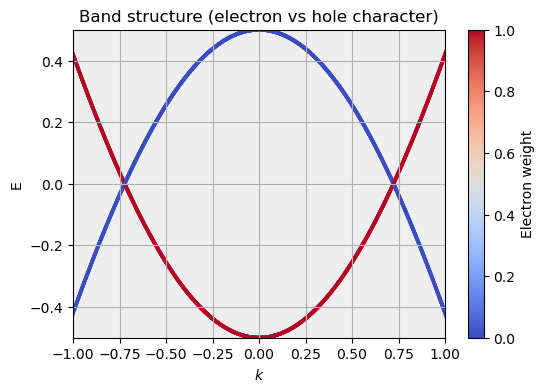

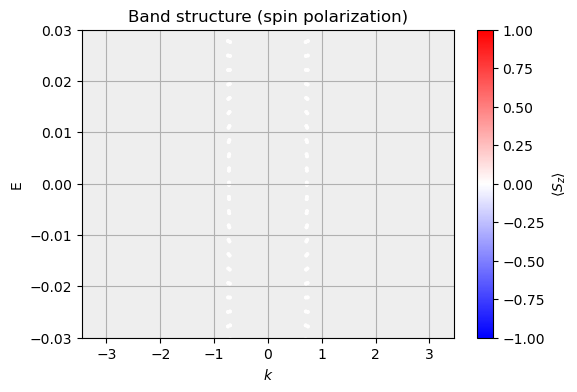

In [23]:
#中间能带
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])
Sz = np.block([
    [sx, np.zeros((2,2))],
    [np.zeros((2,2)), sx]
])

ks = np.linspace(-np.pi, np.pi, 3001)
def Hk(k, H, T):
    return H + T * np.exp(1j*k) + T.conj().T * np.exp(-1j*k)
spin_expect = []
electron_weight = []
energies = []

for k in ks:
    H_k = Hk(k, H_q, T_12)
    evals, evecs = np.linalg.eigh(H_k)

    energies.append(evals)

    # 对每条带计算期望值
    for n in range(len(evals)):
        psi = evecs[:, n]

        w_e = np.real(psi.conj().T @ P_e @ psi)
        s_z = np.real(psi.conj().T @ Sz @ psi)

        electron_weight.append(w_e)
        spin_expect.append(s_z)

energies = np.array(energies)
electron_weight = np.array(electron_weight).reshape(len(ks), -1)
spin_expect = np.array(spin_expect).reshape(len(ks), -1)

from matplotlib.colors import Normalize, TwoSlopeNorm

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 关键：浅灰背景

norm_e = Normalize(vmin=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=electron_weight[:, n],
        cmap='coolwarm',
        norm=norm_e,
        s=3
    )

plt.colorbar(label='Electron weight')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (electron vs hole character)')
plt.grid(True)
plt.ylim(-dela*50,dela*50)
plt.xlim(-1,1)
#plt.ylim(-2,2)
#if save:
#    save_fig_by_title(f"3D_quan")   
#plt.show()

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')

norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=spin_expect[:, n],
        cmap='bwr',
        norm=norm_s,
        s=3
    )

plt.colorbar(label=r'$\langle S_z \rangle$')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (spin polarization)')
plt.grid(True)
plt.ylim(-3*dela,3*dela)
#plt.xlim(-1,1)
if save:
    save_fig_by_title(f"3D")  
plt.show()



已保存图片: D:\结果\2026.4.5\hz=0D_hx=0.0D_a1=0_jiao=0.000_tc=1t_N=2_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=0_TTc=0.001_Delta=0.01meV_t=100.0D_mu=-150.0D\4R.png


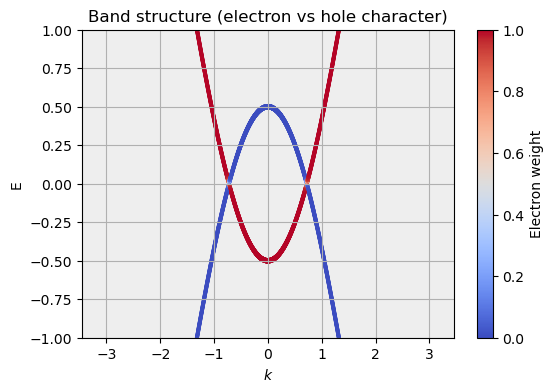

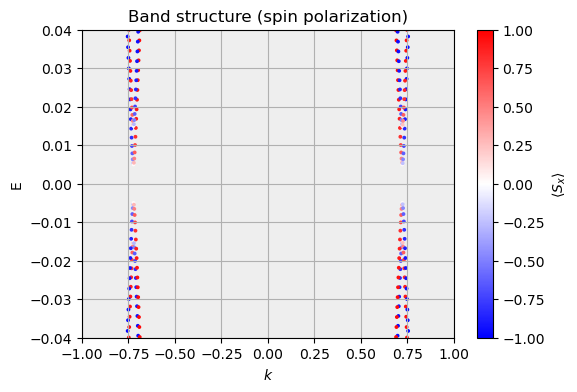

In [107]:
#右边能带
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])
Sz = np.block([
    [sx, np.zeros((2,2))],
    [np.zeros((2,2)), sx]
])

ks = np.linspace(-np.pi, np.pi, 3001)
def Hk(k, H, T):
    return H + T * np.exp(1j*k) + T.conj().T * np.exp(-1j*k)
spin_expect = []
electron_weight = []
energies = []

for k in ks:
    H_k = Hk(k, H_r, T_r)
    evals, evecs = np.linalg.eigh(H_k)

    energies.append(evals)

    # 对每条带计算期望值
    for n in range(len(evals)):
        psi = evecs[:, n]

        w_e = np.real(psi.conj().T @ P_e @ psi)
        s_z = np.real(psi.conj().T @ Sz @ psi)

        electron_weight.append(w_e)
        spin_expect.append(s_z)

energies = np.array(energies)
electron_weight = np.array(electron_weight).reshape(len(ks), -1)
spin_expect = np.array(spin_expect).reshape(len(ks), -1)

from matplotlib.colors import Normalize, TwoSlopeNorm

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 关键：浅灰背景

norm_e = Normalize(vmin=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=electron_weight[:, n],
        cmap='coolwarm',
        norm=norm_e,
        s=3
    )

plt.colorbar(label='Electron weight')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (electron vs hole character)')
plt.grid(True)
#plt.ylim(-dela*60,dela*60)
#plt.xlim(-2,2)
plt.ylim(-1,1)

#if save:
#    save_fig_by_title(f"4R_quan")   
#plt.show()

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')

norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=spin_expect[:, n],
        cmap='bwr',
        norm=norm_s,
        s=3
    )

plt.colorbar(label=r'$\langle S_x \rangle$')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (spin polarization)')
plt.grid(True)
#plt.ylim(-dela*52,-dela*48)
#plt.xlim(-1,-0.5)
#plt.xlim(0.5,1)
#plt.ylim(-dela*60,dela*60)
plt.xlim(-1,1)
plt.ylim(-4*dela,4*dela)
if save:
    save_fig_by_title(f"4R")     
plt.show()



已保存图片: D:\结果\2026.4.5\hz=0D_hx=0.0D_a1=0_jiao=0.000_tc=1t_N=2_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=0_TTc=0.001_Delta=0.01meV_t=100.0D_mu=-150.0D\4R.png


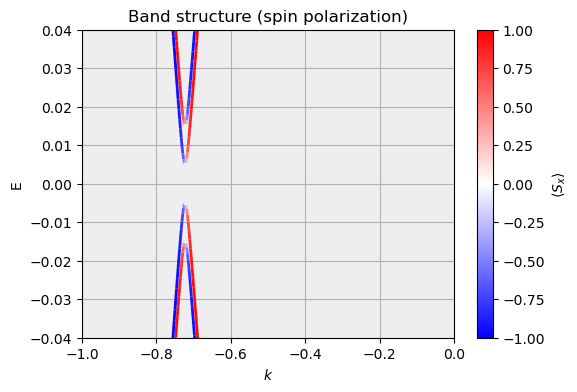

In [110]:
import numpy as np
from matplotlib.collections import LineCollection
# 确保你已经导入了 TwoSlopeNorm 等需要的模块

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')

norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for n in range(energies.shape[1]):
    x = ks
    y = energies[:, n]
    z = spin_expect[:, n]
    
    # 1. 将数据点 (x, y) 重新塑形，准备生成线段
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    # 2. 将相邻的点连接成线段序列：(x0,y0)到(x1,y1)为第一段，(x1,y1)到(x2,y2)为第二段...
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # 3. 使用 LineCollection 绘制线条，并传入颜色映射 (cmap 和 norm)
    lc = LineCollection(segments, cmap='bwr', norm=norm_s)
    
    # 4. 设置这些线段的颜色对应值。这里取每条短线段起点的自旋期望值作为该段的颜色
    lc.set_array(z[:-1]) 
    lc.set_linewidth(2)  # 你可以根据需要调整线宽
    
    # 将生成的线段集合添加到坐标轴中
    line = ax.add_collection(lc)

# 必须显式将最后生成的 LineCollection 对象 (line) 传给 colorbar
plt.colorbar(line, label=r'$\langle S_x \rangle$')

plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (spin polarization)')
plt.grid(True)

plt.xlim(-1, 0)
plt.ylim(-4*dela, 4*dela)

if save:
    save_fig_by_title(f"4R")     
plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_20240\3009816443.py:46: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E/$\Delta$')


已保存图片: D:\结果\2026.4.5\hz=0D_hx=0.0D_a1=0_jiao=0.000_tc=1t_N=2_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=0_TTc=0.001_Delta=0.01meV_t=100.0D_mu=-150.0D\2ABS ceshi.png


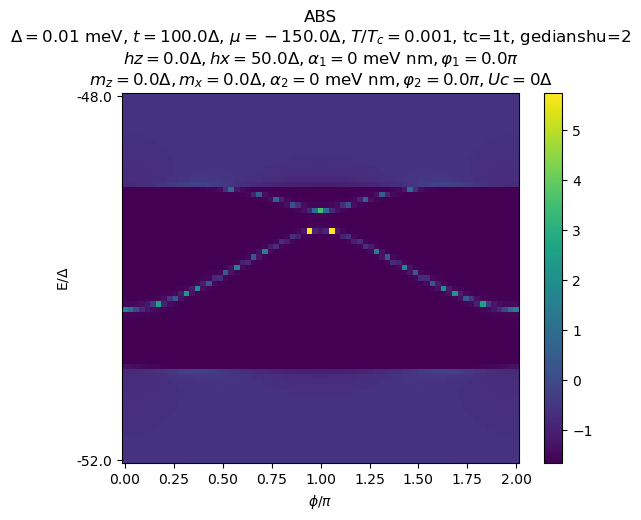

In [82]:
#ABS——态密度扫描
sdsd=10
shangxia=15

num_ef = 70
efmin = -Delta*52#shangxia
efmax = -Delta*48#shangxia
def_ = (efmax - efmin) / num_ef
num_phi = 70
phi_min = 0
phi_max = 2 * np.pi
dphi = (phi_max - phi_min) / num_phi

# Initialize grids
ef_plot = np.zeros(num_ef + 1)
phi_plot = np.zeros(num_phi + 1)
ABS = np.zeros((num_ef + 1, num_phi + 1))

for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    ef_plot[jj] = ef
    for ii in range(num_phi + 1):
        phi = phi_min + dphi * ii
        phi_plot[ii] = phi / np.pi
        
        # Update Delta and H_l, H_r based on phi
        H_r = H_onsite(hx,hz,saimanjiao,3,phi,t)
        
        # Compute G_DD_r
        G_00, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, ef
        )
        
        # Compute ABS (bufeng)
        ABS[jj, ii] = bufeng(G_00)

# Figure
plt.figure()
X, Y = np.meshgrid(phi_plot, ef_plot)
plt.pcolormesh(X, Y, np.log(ABS + 1e-10), shading='auto')  # Added small epsilon to avoid log(0)
plt.colorbar(location='right')
plt.xlabel(r'$\phi$/$\pi$')

plt.ylabel('E/$\Delta$')
plt.yticks(
    [efmin, efmin/2, 0,efmax/2, efmax],
    [efmin/Delta, efmin/Delta/2, 0,efmax/Delta/2, efmax/Delta]
)
plt.title(
    fr'ABS' + '\n' +
    fr'$\Delta = {dela}$ meV, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$, tc={tc}t, gedianshu={N}' + '\n' +
    fr'$hz = {hz/dela}\Delta, hx = {hx/dela}\Delta, \alpha_1 = {af}\text{{ meV nm}}, \varphi_1 = {saimanjiao}\pi$' + '\n' +
    fr'$m_z = {mz/dela}\Delta, m_x = {mx/dela}\Delta, \alpha_2 = {af*af2}\text{{ meV nm}}, \varphi_2 = {zhongjian_saimanjiao}\pi, Uc={U_c}\Delta$'
)
plt.axis('square')
plt.axis('tight')
if save:
    save_fig_by_title(f"2ABS ceshi")
plt.show()

In [83]:
#核心——二极管因子（Jmax-phimax,Jmin-phimin）
shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei+1
print('n*2*np.pi*KBT/Delta=',shumu*2*np.pi*KBT/Delta)
jjalpi=J_of_phi(0.5*np.pi)
print('这时J(phi/2)=',jjalpi)

shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei
print('n*2*np.pi*KBT/Delta=',shumu*2*np.pi*KBT/Delta)
jjalpi2=J_of_phi(0.5*np.pi)
print('这时J(phi/2)=',jjalpi2)


alnalkna=abs(abs(jjalpi2)-abs(jjalpi))/(abs(jjalpi2)+abs(jjalpi))
print('因子差=',alnalkna)

shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei


n*2*np.pi*KBT/Delta= 20.003507783097344
这时J(phi/2)= -1.693346523698286e-05
n*2*np.pi*KBT/Delta= 19.999917391493238
这时J(phi/2)= -1.693160708939687e-05
因子差= 5.486914565194948e-05


In [84]:
#J vs phi
phi_list = np.linspace(0, 2*np.pi, 21) #和下文配备
J_list = []
for phi in phi_list:
    chaodaojiao = phi
    H_r = H_onsite(hx,hz,saimanjiao,3,chaodaojiao,t)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N)

    J_list.append(Jphi)

已保存图片: D:\结果\2026.4.5\hz=0D_hx=0.0D_a1=0_jiao=0.000_tc=1t_N=2_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=0_TTc=0.001_Delta=0.01meV_t=100.0D_mu=-150.0D\5J vs phi.png


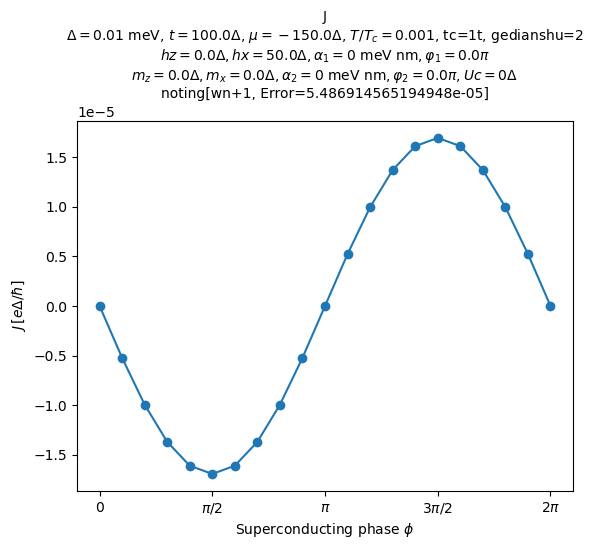

In [85]:
plt.figure()
plt.plot(phi_list, J_list, marker='o')
plt.xlabel(r'Superconducting phase $\phi$')
plt.ylabel(r'$J\,[e\Delta/\hbar]$')
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.title(
    fr'J' + '\n' +
    fr'$\Delta = {dela}$ meV, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$, tc={tc}t, gedianshu={N}' + '\n' +
    fr'$hz = {hz/dela}\Delta, hx = {hx/dela}\Delta, \alpha_1 = {af}\text{{ meV nm}}, \varphi_1 = {saimanjiao}\pi$' + '\n' +
    fr'$m_z = {mz/dela}\Delta, m_x = {mx/dela}\Delta, \alpha_2 = {af*af2}\text{{ meV nm}}, \varphi_2 = {zhongjian_saimanjiao}\pi, Uc={U_c}\Delta$' + '\n' +
    fr'noting[wn+1, Error={alnalkna}]',  # <--- 加上这个逗号！
    fontsize=10
)
if save:
    save_fig_by_title("5J vs phi")
plt.show()

In [163]:
#求导加扫描
base_phi = phi_list # 这里假设你的 phi_list 已经设定好了 (比如 31 个点)
target_centers = np.sort(np.unique(base_phi))

dengchajuli=1e-3*2

# 为所有中心点配备左右辅助点 (+- 1e-4)
phi_with_buffers = np.concatenate([
    target_centers, 
    target_centers - dengchajuli, 
    target_centers + dengchajuli
])

phi_set = np.sort(np.unique(phi_with_buffers))

#sdsd = 0.05
E_min, E_max = -dela* sdsd, 0 

phi_list_1 = []
E_peak_list = []

# --- 2. 核心计算循环 ---
for phi in phi_set:
    chaodaojiao = phi
    H_r = H_onsite(hx, hz, saimanjiao, 3, chaodaojiao,t)
    
    def A_of_E(E):
        G_00, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        return bufeng(G_00)

    # 寻峰逻辑
    peak_energies = find_peaks_fmin(A_of_E, E_min, E_max, N_guess=40, xtol=1e-6, ftol=1e-6)
    valid_peaks = [E for E in peak_energies if E < 0.0 and E > E_min]

    if len(valid_peaks) > 0:
        A_values = [A_of_E(E) for E in valid_peaks]
        best_idx = np.argmax(A_values)
        best_E = valid_peaks[best_idx]
        phi_list_1.append(phi)
        E_peak_list.append(best_E)

# 转换为数组
phi_arr_full = np.array(phi_list_1)
E_arr_full = np.array(E_peak_list)


# --- 3. 手动差分导数计算与数据提取 (带突变清洗与降级容错机制) ---
delta_phi = dengchajuli
energy_tolerance = 0.01  # 设置能量突变容忍度为 0.01

phi_final_list = []
E_final_list = []
dE_dphi_final_list = []

for p in target_centers:
    # 定位中心点及其左右辅助点
    idx_p = np.where(np.isclose(phi_arr_full, p, atol=1e-7))[0]
    idx_left = np.where(np.isclose(phi_arr_full, p - delta_phi, atol=1e-7))[0]
    idx_right = np.where(np.isclose(phi_arr_full, p + delta_phi, atol=1e-7))[0]
    
    # 只要中心点存在，我们就尝试去算它的导数
    if len(idx_p) > 0:
        E_p = E_arr_full[idx_p[0]]
        deriv = 0.0 # 默认导数
        
        # 提取辅助点能量（如果存在）
        E_left = E_arr_full[idx_left[0]] if len(idx_left) > 0 else None
        E_right = E_arr_full[idx_right[0]] if len(idx_right) > 0 else None
        
        # --- 核心清洗：检查能量突变 ---
        # 如果左右护法的能量和中心点偏差过大(>0.01)，则将它们视为无效点
        if E_left is not None and abs(E_left - E_p) > energy_tolerance:
            E_left = None
            
        if E_right is not None and abs(E_right - E_p) > energy_tolerance:
            E_right = None

        # --- 导数计算 (梯队降级) ---
        # 1. 理想情况：左右有效护法都在，使用高精度中心差分
        if E_left is not None and E_right is not None:
            deriv = (E_right - E_left) / (2 * delta_phi)
            
        # 2. 只有右边有效，使用前向差分
        elif E_right is not None:
            deriv = (E_right - E_p) / delta_phi
            
        # 3. 只有左边有效，使用后向差分
        elif E_left is not None:
            deriv = (E_p - E_left) / delta_phi
            
        # 4. 左右有效点都没了，导数只能记作 0
        else:
            print(f"警告: 相位 {p/np.pi:.3f}pi 处缺乏有效的辅助点(或突变过大)，导数设为 0")
            deriv = 0.0
            
        # 记录清洗后的数据
        phi_final_list.append(p)
        E_final_list.append(E_p)
        dE_dphi_final_list.append(deriv)

# 转换为 Numpy 数组
phi_final = np.array(phi_final_list)
E_final = np.array(E_final_list)
dE_dphi_final = np.array(dE_dphi_final_list)

In [164]:
len(phi_final)

21

<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taoji\AppData\Local\Temp\ipykernel_32660\2128599901.py:50: SyntaxWarning: invalid escape sequence '\p'
  save_fig_by_title(f"1ABS $\partial E / \partial \phi$")


已保存图片: D:\结果\2026.4.5\hz=0.5D_hx=0.5D_a1=50_jiao=0.000_tc=1t_N=20_mz=0.5D_mx=0.5D_a2=50_zjiao=0.000_Uc=0_TTc=0.0001_Delta=1meV_t=200.0D_mu=0.0D\0ABS.png


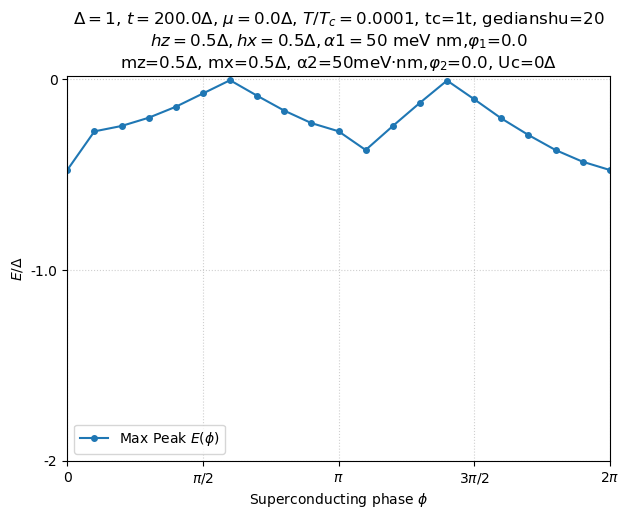

已保存图片: D:\结果\2026.4.5\hz=0.5D_hx=0.5D_a1=50_jiao=0.000_tc=1t_N=20_mz=0.5D_mx=0.5D_a2=50_zjiao=0.000_Uc=0_TTc=0.0001_Delta=1meV_t=200.0D_mu=0.0D\1ABS __partial E _ _partial _phi_.png


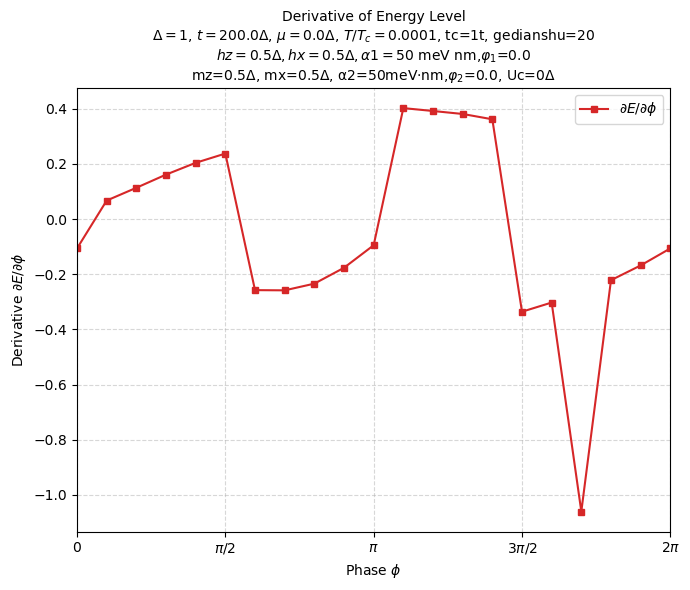

In [165]:
#绘图ABS观察
plt.figure(figsize=(7, 5))
# 使用 r 前缀处理 label
plt.plot(phi_final, E_final, 'o-', color='tab:blue', markersize=4, label=r'Max Peak $E(\phi)$')

plt.xlabel(r"Superconducting phase $\phi$")
plt.ylabel(r"$E / \Delta$")
# 使用 fr 前缀处理带变量的 LaTeX 标题
plt.title(fr'$\Delta = {dela}$, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$, tc={tc}t, gedianshu={N}' + '\n' +
    fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha1 = {af}$ meV nm,$\varphi_1$={saimanjiao}' + '\n' + 
    fr'mz={mz}Δ, mx={mx}Δ, α2={af*af2}meV·nm,$\varphi_2$={zhongjian_saimanjiao}, Uc={U_c}$\Delta$' )

plt.xlim(0, 2*np.pi)
#plt.ylim(E_min, 0.1)
plt.yticks([-dela*sdsd, -dela*sdsd/2, 0], [-1*sdsd, -1*sdsd/2, 0])
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
#plt.xlim(1.79*np.pi,1.81*np.pi)
#plt.ylim(-0.01,0.01)
if save:
    save_fig_by_title(f"0ABS")
plt.show()

# --- 5. 绘图：导数图 ---
plt.figure(figsize=(7, 6)) 
plt.plot(phi_final, dE_dphi_final, 's-', color='tab:red', markersize=4, label=r'$\partial E / \partial \phi$')

# 使用 fr 处理 axvline 的标签

plt.xlabel(r"Phase $\phi$")
plt.ylabel(r"Derivative $\partial E / \partial \phi$")

# 使用 fr 格式化大标题，避免转义错误
plt.title(
    fr'Derivative of Energy Level' + '\n' +
    fr'$\Delta = {dela}$, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$, tc={tc}t, gedianshu={N}' + '\n' +
    fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha1 = {af}$ meV nm,$\varphi_1$={saimanjiao}' + '\n' + 
    fr'mz={mz}Δ, mx={mx}Δ, α2={af*af2}meV·nm,$\varphi_2$={zhongjian_saimanjiao}, Uc={U_c}$\Delta$' ,
    fontsize=10
)

plt.xlim(0, 2*np.pi)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
#plt.ylim(-1,1)
if save:
    save_fig_by_title(f"1ABS $\partial E / \partial \phi$")
plt.show()

In [166]:
#数据保存
# ==========================================
J_final = []
shumu = int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei

for phi in phi_final:
    # 检查当前的 phi 是否已经存在于原来的 phi_list 中 (用 isclose 避免浮点误差)
    match_idx = np.where(np.isclose(phi_list, phi, atol=1e-7))[0]
    
    if len(match_idx) > 0:
        # 如果已经算过了，直接从 J_list 提取现成的值
        J_final.append(J_list[match_idx[0]])
    else:
        # 万一有额外点 (理论上现在没有了)，则单独算一次
        H_r_J = H_onsite(hx, hz, saimanjiao, 3, phi)
        Jphi = J_matsubara_sum(shumu, H_q, H_l, H_r_J, T_12, T_LD, T_l, T_RD, T_r, N, q)
        J_final.append(Jphi)

J_final = np.array(J_final)

# 第四列：电流减去能级导数
diff_J_dE = J_final - dE_dphi_final

# ==========================================
# --- 核心修改：在 31 个点中寻找极值并做标记 ---
# ==========================================
# 自动在计算出的 J_final 数组中找出最大值和最小值的索引
idx_max = np.argmax(J_final)
idx_min = np.argmin(J_final)

# 初始化一个全为字符 '0' 的字符串数组
marker_col = np.full(phi_final.shape, '0', dtype=object)
# 针对找到的索引打上 max 和 min 标记
marker_col[idx_max] = 'max'  
marker_col[idx_min] = 'min'  

# ==========================================
# --- 2. 构造整合后的保存目录与文件头 ---
# ==========================================

# 清洗文件夹名称中的非法字符
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')

save_dir = save_dir 
os.makedirs(save_dir, exist_ok=True)

# 提取局部极值用于显示在报告头部
local_phi_max = phi_final[idx_max] / np.pi
local_phi_min = phi_final[idx_min] / np.pi
# ==========================================
# 提前计算非倒易率 (Non-reciprocity / Diode Efficiency)
# ==========================================
j_max_val = J_final[idx_max]
j_min_val = J_final[idx_min]

# 防止分母为0导致报错
if abs(j_max_val) + abs(j_min_val) != 0:
    non_reciprocity = abs(abs(j_max_val) - abs(j_min_val)) / (abs(j_max_val) + abs(j_min_val))
else:
    non_reciprocity = 0.0

delta_J = j_max_val + j_min_val

# ==========================================
# 构造合并后的报告头部信息
# ==========================================
header_info = (
    "="*80 + "\n"
    + f"{'ABS CURRENT ANALYSIS REPORT':^80}\n"
    + "="*80 + "\n"
    + f"Parameters: Δ={dela}meV, t={t/dela:.1f}Δ, μ={mu/dela:.1f}Δ, T/Tc={T_Tc}, tc={tc}, gedianshu={N}\n"
    + f"            hz={hz}Δ, hx={hx}Δ, α1={af}meV·nm, varphi1={saimanjiao}\n"
    + f"            mz={mz}Δ, mx={mx}Δ, α2={af*af2}meV·nm, varphi2={zhongjian_saimanjiao}, Uc={U_c}meV\n"
    + f"            noting[wn+1, The error value caused by the maximum value={alnalkna}]\n"
    + "-" * 80 + "\n"
    + "-" * 60 + "\n"
    + f"[@ Local Max Current Found at Phase φ = {local_phi_max:.3f}π]\n"
    + f"  > Total Current (Jmax)        : {j_max_val:10.6f}\n"
    + f"  > Bound State Current (∂E/∂φ) : {dE_dphi_final[idx_max]:10.6f}\n"
    + f"  > Difference (Jmax - ∂E/∂φ)   : {diff_J_dE[idx_max]:10.6f}\n"
    + "-" * 60 + "\n"
    + f"[@ Local Min Current Found at Phase φ = {local_phi_min:.3f}π]\n"
    + f"  > Total Current (Jmin)        : {j_min_val:10.6f}\n"
    + f"  > Bound State Current (∂E/∂φ) : {dE_dphi_final[idx_min]:10.6f}\n"
    + f"  > Difference (Jmin - ∂E/∂φ)   : {diff_J_dE[idx_min]:10.6f}\n"
    + "-" * 60 + "\n"
    + f"[@ Non-reciprocity Analysis]\n"
    + f"  > Delta J (Jmax + Jmin)       : {delta_J:10.6f}\n"
    + f"  > Efficiency (|Jmax|-|Jmin|) / (|Jmax|+|Jmin|) : {non_reciprocity:10.6f} ({non_reciprocity*100:.2f}%)\n"
    + "="*60 + "\n"
    + "phi/pi\t\tEnergy_E\t\tJ_current\t\tdE_dphi\t\tJ_minus_dE\t\tMarker"
)
# ==========================================
# --- 3. 执行保存 ---
# ==========================================
if save:
    # 核心修改：合并 6 列数据
    data_to_save = np.column_stack((phi_final/np.pi, E_final, J_final, dE_dphi_final, diff_J_dE, marker_col))
    
    # 定义整合后的文件名
    txt_filename = os.path.join(save_dir, "6相位_能量_电流J_能级导数.txt")
    
    # 使用 numpy 格式化写入
    np.savetxt(
        txt_filename, 
        data_to_save, 
        header=header_info,  
        fmt=["%16.8e", "%16.8e", "%16.8e", "%16.8e", "%16.8e", "%6s"], 
        delimiter="\t", 
        comments="" 
    )
    
    # 同时在控制台打印头部，确认信息
    print(header_info)
    print(f"--- 整合报告及数据已成功保存至: {txt_filename} ---")

                          ABS CURRENT ANALYSIS REPORT                           
Parameters: Δ=1meV, t=200.0Δ, μ=0.0Δ, T/Tc=0.0001, tc=1, gedianshu=20
            hz=0.5Δ, hx=0.5Δ, α1=50meV·nm, varphi1=0.0
            mz=0.5Δ, mx=0.5Δ, α2=50meV·nm, varphi2=0.0, Uc=0meV
            noting[wn+1, The error value caused by the maximum value=6.274581939101989e-07]
--------------------------------------------------------------------------------
------------------------------------------------------------
[@ Local Max Current Found at Phase φ = 0.500π]
  > Total Current (Jmax)        :   0.384214
  > Bound State Current (∂E/∂φ) :   0.237500
  > Difference (Jmax - ∂E/∂φ)   :   0.146714
------------------------------------------------------------
[@ Local Min Current Found at Phase φ = 1.500π]
  > Total Current (Jmin)        :  -0.462252
  > Bound State Current (∂E/∂φ) :  -0.335750
  > Difference (Jmin - ∂E/∂φ)   :  -0.126502
------------------------------------------------------------
[@ Non-r

已保存图片: D:\结果\2026.4.5\hz=0.5D_hx=0.5D_a1=50_jiao=0.000_tc=1t_N=20_mz=0.5D_mx=0.5D_a2=50_zjiao=0.000_Uc=0_TTc=0.0001_Delta=1meV_t=200.0D_mu=0.0D\7相位_电流J_能级导数_图.png


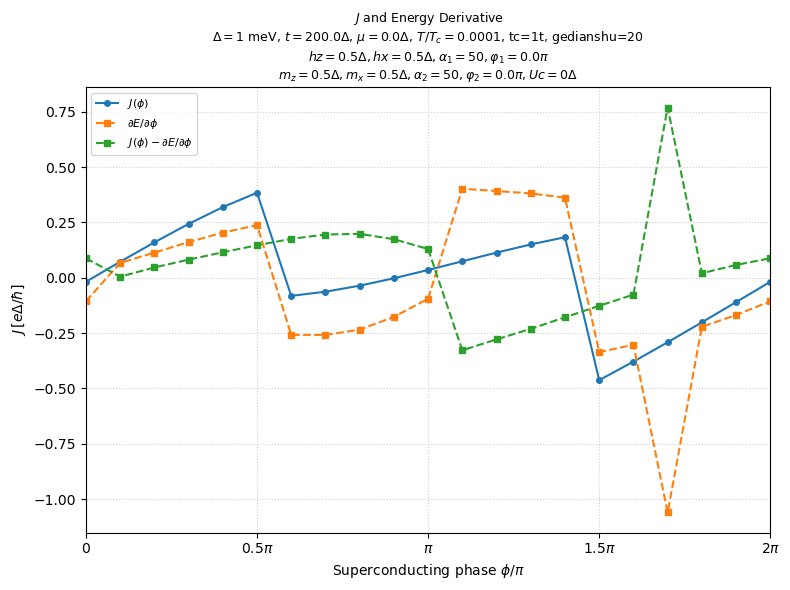

In [167]:
# --- 绘制：8相位_电流J_能级导数_图 ---
plt.figure(figsize=(8, 6))

# 2. 绘制主要数据曲线
# 横轴使用 phi_final/np.pi
plt.plot(phi_final/np.pi, J_final, 'o-', color='tab:blue', markersize=4, label=r'$J(\phi)$')
plt.plot(phi_final/np.pi, dE_dphi_final, 's--', color='tab:orange', markersize=4, label=r'$\partial E / \partial \phi$')
plt.plot(phi_final/np.pi, diff_J_dE, 's--', color='tab:green', markersize=4, label=r'$J(\phi)-\partial E / \partial \phi$')


# 4. 坐标轴设置
plt.xlabel(r'Superconducting phase $\phi / \pi$')
plt.ylabel(r'$J\,[e\Delta/\hbar]$')
plt.xlim(0, 2)
#plt.ylim(-1, 1)  # 限制 Y 轴范围在 -1 到 1，防止数值噪声干扰
plt.xticks([0, 0.5, 1, 1.5, 2], ['0', r'$0.5\pi$', r'$\pi$', r'$1.5\pi$', r'$2\pi$'])

# 5. 构建详细标题
plt.title(
    fr'$J$ and Energy Derivative' + '\n' +
    fr'$\Delta = {dela}$ meV, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$, tc={tc}t, gedianshu={N}' + '\n' +
    fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha_1 = {af}, \varphi_1 = {saimanjiao}\pi$' + '\n' +
    fr'$m_z = {mz}\Delta, m_x = {mx}\Delta, \alpha_2 = {af*af2}, \varphi_2 = {zhongjian_saimanjiao}\pi, Uc={U_c}\Delta$',
    fontsize=9
)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=8)
plt.tight_layout()

# 6. 保存与显示
if save:
    save_fig_by_title("7相位_电流J_能级导数_图")
plt.show()

已保存图片: D:\结果\2026.4.5\hz=0.5D_hx=0.5D_a1=50_jiao=0.000_tc=1t_N=20_mz=0.5D_mx=0.5D_a2=50_zjiao=0.000_Uc=0_TTc=0.0001_Delta=1meV_t=200.0D_mu=0.0D\7相位_连续态_图.png


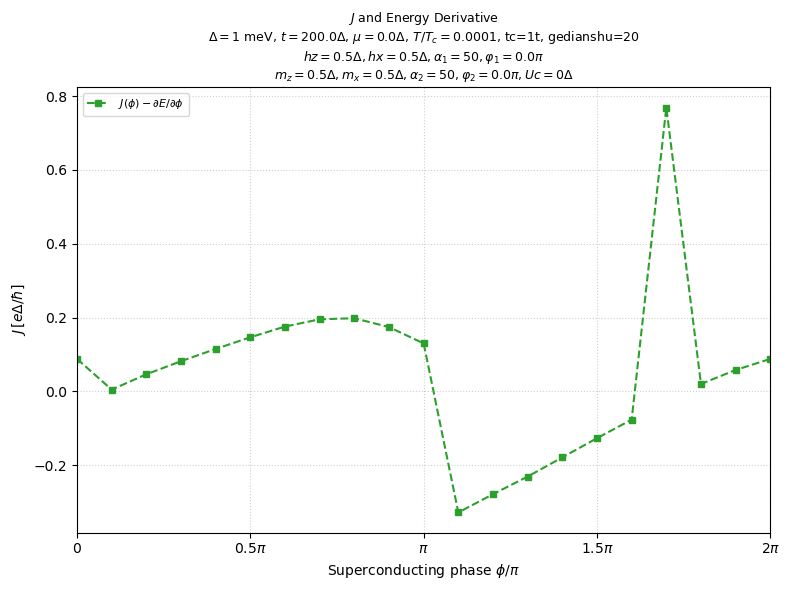

In [168]:
# --- 绘制：8相位_电流J_图 --
plt.figure(figsize=(8, 6))

# 2. 绘制主要数据曲线
# 横轴使用 phi_final/np.pi
#plt.plot(phi_final/np.pi, J_final, 'o-', color='tab:blue', markersize=4, label=r'$J(\phi)$')
#plt.plot(phi_final/np.pi, dE_dphi_final, 's--', color='tab:orange', markersize=4, label=r'$\partial E / \partial \phi$')
plt.plot(phi_final/np.pi, diff_J_dE, 's--', color='tab:green', markersize=4, label=r'$J(\phi)-\partial E / \partial \phi$')


# 4. 坐标轴设置
plt.xlabel(r'Superconducting phase $\phi / \pi$')
plt.ylabel(r'$J\,[e\Delta/\hbar]$')
plt.xlim(0, 2)
#plt.ylim(-1, 1)  # 限制 Y 轴范围在 -1 到 1，防止数值噪声干扰
plt.xticks([0, 0.5, 1, 1.5, 2], ['0', r'$0.5\pi$', r'$\pi$', r'$1.5\pi$', r'$2\pi$'])

# 5. 构建详细标题
plt.title(
    fr'$J$ and Energy Derivative' + '\n' +
    fr'$\Delta = {dela}$ meV, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$, tc={tc}t, gedianshu={N}' + '\n' +
    fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha_1 = {af}, \varphi_1 = {saimanjiao}\pi$' + '\n' +
    fr'$m_z = {mz}\Delta, m_x = {mx}\Delta, \alpha_2 = {af*af2}, \varphi_2 = {zhongjian_saimanjiao}\pi, Uc={U_c}\Delta$',
    fontsize=9
)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=8)
plt.tight_layout()

# 6. 保存与显示
if save:
    save_fig_by_title("7相位_连续态_图")
plt.show()